In [1]:
import os, sys, pickle, emcee, copy
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pyswarms as ps

from lenstronomy.Util import param_util
from lenstronomy.Data.imaging_data import ImageData
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.Workflow.fitting_sequence import FittingSequence
from lenstronomy.LensModel.Solver.lens_equation_solver import LensEquationSolver
from lenstronomy.Plots.model_plot import ModelPlot

sys.path.append("../src")

from iful.util import *
from iful.image_set import *
from iful.flat_modeling import *

In [2]:
with open("s4_models/imset4.pickle", "rb") as handle:
    imset4 = pickle.load(handle)

if Path("s4_models/flatmodel4.pickle").exists():
    with open("s4_models/flatmodel4.pickle", "rb") as handle:
        flatmodel4 = pickle.load(handle)
else:
    flatmodel4 = FlatModel(
        imset4, ["EPL_Q_PHI", "SIS", "SIS", "SHEAR"], ["SERSIC_ELLIPSE"]
    )

In [3]:
from astropy.cosmology import FlatLambdaCDM
from lenstronomy.Cosmo.lens_cosmo import LensCosmo

lensCosmo = LensCosmo(
    cosmo=FlatLambdaCDM(H0=70, Om0=0.3),
    z_lens=imset4.aux_info["zl"],
    z_source=imset4.zs,
)

vd = 261
vd_err = 3
ld_ein_d = lensCosmo.dds / lensCosmo.ds * 4 * np.pi * vd**2 / 299792**2 * 206265
ld_ein_d_err = (
    lensCosmo.dds / lensCosmo.ds * 4 * np.pi * 2 * vd * vd_err / 299792**2 * 206265
)

vd = 313
vd_err = 4
ld_ein_f = lensCosmo.dds / lensCosmo.ds * 4 * np.pi * vd**2 / 299792**2 * 206265
ld_ein_f_err = (
    lensCosmo.dds / lensCosmo.ds * 4 * np.pi * 2 * vd * vd_err / 299792**2 * 206265
)

print(f"theta_d = {ld_ein_d:.3f} +- {ld_ein_d_err:.3f}")
print(f"theta_f = {ld_ein_f:.3f} +- {ld_ein_f_err:.3f}")

theta_d = 1.104 +- 0.025
theta_f = 1.588 +- 0.041


In [4]:
lens_model_list = [flatmodel4.lensmodel[0]]
lensModel = LensModel(lens_model_list=lens_model_list)
solver = LensEquationSolver(lensModel)

init_lens_center_pix = flatmodel4.convert_pixel_to_ra_dec(
    imset4.aux_info["init_lens_center"]
)

points_dst = flatmodel4.init_img_centers[:-1]

nwalkers = 500
options = {"c1": 0.5, "c2": 0.3, "w": 0.9}


def minfun_(xl):
    resp = []
    for x in xl:
        kwargs_lens = []

        gam, qq, phi, cx, cy, sx, sy = x
        kwargs_lens += [
            {
                "theta_E": 12.7,
                "gamma": gam,
                "q": qq,
                "phi": phi,
                "center_x": cx,
                "center_y": cy,
            }
        ]

        kwargs_lens += [
            {
                "theta_E": ld_ein_d,
                "center_x": init_lens_center_pix[1, 0],
                "center_y": init_lens_center_pix[1, 1],
            }
        ]
        kwargs_lens += [
            {
                "theta_E": ld_ein_f,
                "center_x": init_lens_center_pix[2, 0],
                "center_y": init_lens_center_pix[2, 1],
            }
        ]

        rai, deci = solver.image_position_lenstronomy(
            sx, sy, kwargs_lens, search_window=30, magnification_limit=0
        )

        if len(rai) != 4:
            resp += [np.inf]
            continue

        points_src = np.array([rai, deci]).T

        resp += [homography_loss(points_src, points_dst)]
    return resp


bounds = [[1.0, 0.3, -1 * np.pi, -5, -5, -7, -7], [2.9, 1, np.pi, 5, 5, 7, 7]]

init_pos_center = np.array(
    [
        # 12.7,
        1.7,
        0.7172905706153665,
        -1.12546720276278,
        -0.8386123562294033,
        -0.18020722035500997,
        0.684894874199283,
        0.9487598965425639,
    ]
)
init_pos = np.array(
    [
        [
            # np.random.uniform(10, 15),
            np.random.uniform(1.1, 2.1),
            # np.random.uniform(1.1, 1.2),
            np.random.uniform(0.5, 0.9),
            np.random.uniform(-1 * np.pi, np.pi),
            # np.random.uniform(-0.20, -0.15),
            # np.random.uniform(-0.15, -0.10),
            np.random.uniform(-1, 1),
            np.random.uniform(-1, 1),
            np.random.uniform(-1, 1),
            np.random.uniform(-1, 1),
        ]
        for _ in np.arange(nwalkers - 1)
    ]
    + [init_pos_center]
)

optimizer = ps.single.GlobalBestPSO(
    n_particles=nwalkers,
    dimensions=len(bounds[0]),
    options=options,
    bounds=bounds,
    init_pos=init_pos,
)

if flatmodel4.init_pos_fit is None:
    cost, pos = optimizer.optimize(minfun_, iters=500, n_processes=60)
    flatmodel4.init_pos_fit = copy.deepcopy(pos)
else:
    pos = flatmodel4.init_pos_fit

gam, qq, phi, cx, cy, sx, sy = x = copy.deepcopy(pos)
kwargs_lens = [
    {"theta_E": 12.7, "gamma": gam, "q": qq, "phi": phi, "center_x": cx, "center_y": cy},
    {
        "theta_E": ld_ein_d,
        "center_x": init_lens_center_pix[1, 0],
        "center_y": init_lens_center_pix[1, 1],
    },
    {
        "theta_E": ld_ein_f,
        "center_x": init_lens_center_pix[2, 0],
        "center_y": init_lens_center_pix[2, 1],
    },
]
kwargs_lens

[{'theta_E': 12.7,
  'gamma': np.float64(1.4999885982987504),
  'q': np.float64(0.7046198104524831),
  'phi': np.float64(-1.2384530190281113),
  'center_x': np.float64(-0.9844307202771476),
  'center_y': np.float64(0.18600385126776098)},
 {'theta_E': np.float64(1.1039341817028954),
  'center_x': np.float64(-6.199999974592174),
  'center_y': np.float64(17.999999954349732)},
 {'theta_E': np.float64(1.5876356460893257),
  'center_x': np.float64(27.399999567933264),
  'center_y': np.float64(-28.999999808979737)}]

/tmp/ipykernel_1273255/459806703.py:1: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(imset4.datacube_whitelight))
/tmp/ipykernel_1273255/459806703.py:1: RuntimeWarning: invalid value encountered in log10
  plt.imshow(np.log10(imset4.datacube_whitelight))


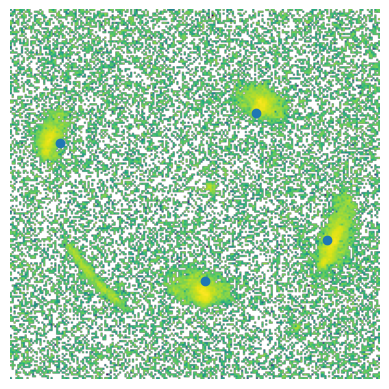

In [5]:
plt.imshow(np.log10(imset4.datacube_whitelight))

rai, deci = solver.image_position_lenstronomy(sx, sy, kwargs_lens, search_window=30)
xi, yi = ImageData(**flatmodel4.multi_band_list[0]).map_coord2pix(rai, deci)
plt.scatter(xi, yi)
plt.gca().invert_yaxis()
plt.axis('off')
plt.show()

In [6]:
with open("s4_models/flatmodel4.pickle", "wb") as handle:
    pickle.dump(flatmodel4, handle, protocol=pickle.HIGHEST_PROTOCOL)

## fitting lens light

In [7]:
lens_model_list = flatmodel4.lensmodel
source_model_list = flatmodel4.sourcemodel
point_source_list = []
lens_light_model_list = []

threadCount = 60

In [8]:
fixed_lens = []
kwargs_lens_init = []
kwargs_lens_sigma = []
kwargs_lower_lens = []
kwargs_upper_lens = []

kwargs_constraints = {"linear_solver": True}

# joint_source_with_source = []
# joint_source_with_source.append([0, 1, ['center_x', 'center_y', 'e1', 'e2']])
# kwargs_constraints['joint_source_with_source'] = joint_source_with_source

fixed_lens.append({})
kwargs_lens_init.append(kwargs_lens[0])
kwargs_lower_lens.append(
    {
        "theta_E": 9,
        "gamma": 1,
        "q": 0,
        "phi": -1 * np.pi,
        "center_x": -5,
        "center_y": -5,
    }
)
kwargs_upper_lens.append(
    {"theta_E": 18, "gamma": 3, "q": 1, "phi": np.pi, "center_x": 5, "center_y": 5}
)
kwargs_lens_sigma.append(
    {
        "theta_E": 0.1,
        "gamma": 0.1,
        "q": 0.1,
        "phi": 0.1,
        "center_x": 0.1,
        "center_y": 0.1,
    }
)

fixed_lens.append({"center_x": kwargs_lens[1]['center_x'], "center_y": kwargs_lens[1]['center_y']})
kwargs_lens_init.append(kwargs_lens[1])
kwargs_lower_lens.append({"theta_E": 0, "center_x": -100, "center_y": -100})
kwargs_upper_lens.append({"theta_E": 3, "center_x": 100, "center_y": 100})
kwargs_lens_sigma.append(
    {"theta_E": 0.1, "center_x": 0.1, "center_y": 0.1}
)

fixed_lens.append({"center_x": kwargs_lens[2]['center_x'], "center_y": kwargs_lens[2]['center_y']})
kwargs_lens_init.append(kwargs_lens[2])
kwargs_lower_lens.append({"theta_E": 0, "center_x": -100, "center_y": -100})
kwargs_upper_lens.append({"theta_E": 5, "center_x": 100, "center_y": 100})
kwargs_lens_sigma.append(
    {"theta_E": 0.1, "center_x": 0.1, "center_y": 0.1}
)

fixed_lens.append({"ra_0": 0, "dec_0": 0})
kwargs_lens_init.append({"gamma1": 0, "gamma2": 0})
kwargs_lens_sigma.append({"gamma1": 0.1, "gamma2": 0.1})
kwargs_lower_lens.append({"gamma1": -0.2, "gamma2": -0.2})
kwargs_upper_lens.append({"gamma1": 0.2, "gamma2": 0.2})

lens_params = [
    kwargs_lens_init,
    kwargs_lens_sigma,
    fixed_lens,
    kwargs_lower_lens,
    kwargs_upper_lens,
]

fixed_source = []
kwargs_source_init = []
kwargs_source_sigma = []
kwargs_lower_source = []
kwargs_upper_source = []

fixed_source.append({})
kwargs_source_init.append(
    {"n_sersic": 4, "R_sersic": 0.23, "e1": 0, "e2": 0, "center_x": sx, "center_y": sy}
)
kwargs_source_sigma.append(
    {
        "n_sersic": 1,
        "R_sersic": 0.3,
        "e1": 0.05,
        "e2": 0.05,
        "center_x": 0.1,
        "center_y": 0.1,
    }
)
kwargs_lower_source.append(
    {
        "e1": -0.75,
        "e2": -0.75,
        "R_sersic": 0.001,
        "n_sersic": 0.1,
        "center_x": sx - 5,
        "center_y": sy - 5,
    }
)
kwargs_upper_source.append(
    {
        "e1": 0.75,
        "e2": 0.75,
        "R_sersic": 10,
        "n_sersic": 10.0,
        "center_x": sx + 5,
        "center_y": sy + 5,
    }
)

# fixed_source.append({'n_max': 3})
# kwargs_source_init.append({'beta': 0.13, 'e1': 0., 'e2': 0, 'center_x': sx, 'center_y': sy})
# kwargs_source_sigma.append({'beta': 0.05, 'e1': 0.05, 'e2': 0.05, 'center_x': 0.1, 'center_y': 0.1})
# kwargs_lower_source.append({'beta': 1e-10, 'e1': -0.75, 'e2': -0.75, 'center_x': sx-1, 'center_y': sy-1})
# kwargs_upper_source.append({'beta': 10, 'e1': 0.75, 'e2': 0.75, 'center_x': sx+1, 'center_y': sy+1})

source_params = [
    kwargs_source_init,
    kwargs_source_sigma,
    fixed_source,
    kwargs_lower_source,
    kwargs_upper_source,
]

lens_light_params = [[], [], [], [], []]
ps_params = [[], [], [], [], []]

kwargs_params = {
    "lens_model": lens_params,
    "source_model": source_params,
    "lens_light_model": lens_light_params,
    "point_source_model": ps_params,
}

gaussian_prior_list = (
    [[1, 'theta_E', ld_ein_d, ld_ein_d_err], [2, 'theta_E', ld_ein_f, ld_ein_f_err]]
)  

In [9]:
kwargs_likelihood = {
    "image_likelihood_mask_list": np.array([imset4.mask]),
    "check_positive_flux": True,
    "prior_lens": gaussian_prior_list,
}  
kwargs_model = {
    "lens_model_list": lens_model_list,
    "source_light_model_list": source_model_list,
    "lens_light_model_list": lens_light_model_list,
    "point_source_model_list": point_source_list,
    "fixed_magnification_list": [False],
}

multi_band_list = [flatmodel4.multi_band_list]
kwargs_data_joint = {
    "multi_band_list": multi_band_list,
    "multi_band_type": "single-band",
}

fitting_seq = FittingSequence(
    kwargs_data_joint,
    kwargs_model,
    kwargs_constraints,
    kwargs_likelihood,
    kwargs_params,
)

fitting_kwargs_list = [
    [
        "PSO",
        {
            "sigma_scale": 1,
            "n_particles": 3000,
            "n_iterations": 5000,
            "threadCount": threadCount,
        },
    ],
]

if flatmodel4.init_pso_fit is None:
    chain_list = fitting_seq.fit_sequence(fitting_kwargs_list)
    kwargs_result = fitting_seq.best_fit()
    flatmodel4.init_pso_fit = kwargs_result
    flatmodel4.init_pso_fitting_seq = fitting_seq
else:
    kwargs_result = flatmodel4.init_pso_fit
    fitting_seq = flatmodel4.init_pso_fitting_seq

In [10]:
print("checking lens params")
[
    check_near_bounds(
        kwargs_result["kwargs_lens"][i], kwargs_lower_lens[i], kwargs_upper_lens[i], i
    )
    for i in np.arange(len(kwargs_lower_lens))
]

print("checking source params")
[
    check_near_bounds(
        kwargs_result["kwargs_source"][i],
        kwargs_lower_source[i],
        kwargs_upper_source[i],
        i,
    )
    for i in np.arange(len(kwargs_upper_source))
]

checking lens params
profile 1 parameter theta_E near lower bound (value 2.552077096045611e-07, bound 0)
checking source params


[None]

-4.241246316326929 reduced X^2 of all evaluated imaging data combined (without degrees of freedom subtracted).
reduced chi^2 of data  0 =  4.24124631632693


/global/homes/w/wsheu1/.conda/envs/iful/lib/python3.11/site-packages/lenstronomy/Plots/model_band_plot.py:68: RuntimeWarning: divide by zero encountered in log10
  log_model = np.log10(model)
/global/homes/w/wsheu1/.conda/envs/iful/lib/python3.11/site-packages/lenstronomy/Plots/model_band_plot.py:68: RuntimeWarning: invalid value encountered in log10
  log_model = np.log10(model)
/global/homes/w/wsheu1/.conda/envs/iful/lib/python3.11/site-packages/lenstronomy/Plots/model_band_plot.py:161: RuntimeWarning: divide by zero encountered in log10
  np.log10(self._data),
/global/homes/w/wsheu1/.conda/envs/iful/lib/python3.11/site-packages/lenstronomy/Plots/model_band_plot.py:161: RuntimeWarning: invalid value encountered in log10
  np.log10(self._data),
/global/homes/w/wsheu1/.conda/envs/iful/lib/python3.11/site-packages/lenstronomy/Plots/model_band_plot.py:225: RuntimeWarning: divide by zero encountered in log10
  np.log10(self._model),
/global/homes/w/wsheu1/.conda/envs/iful/lib/python3.11/s

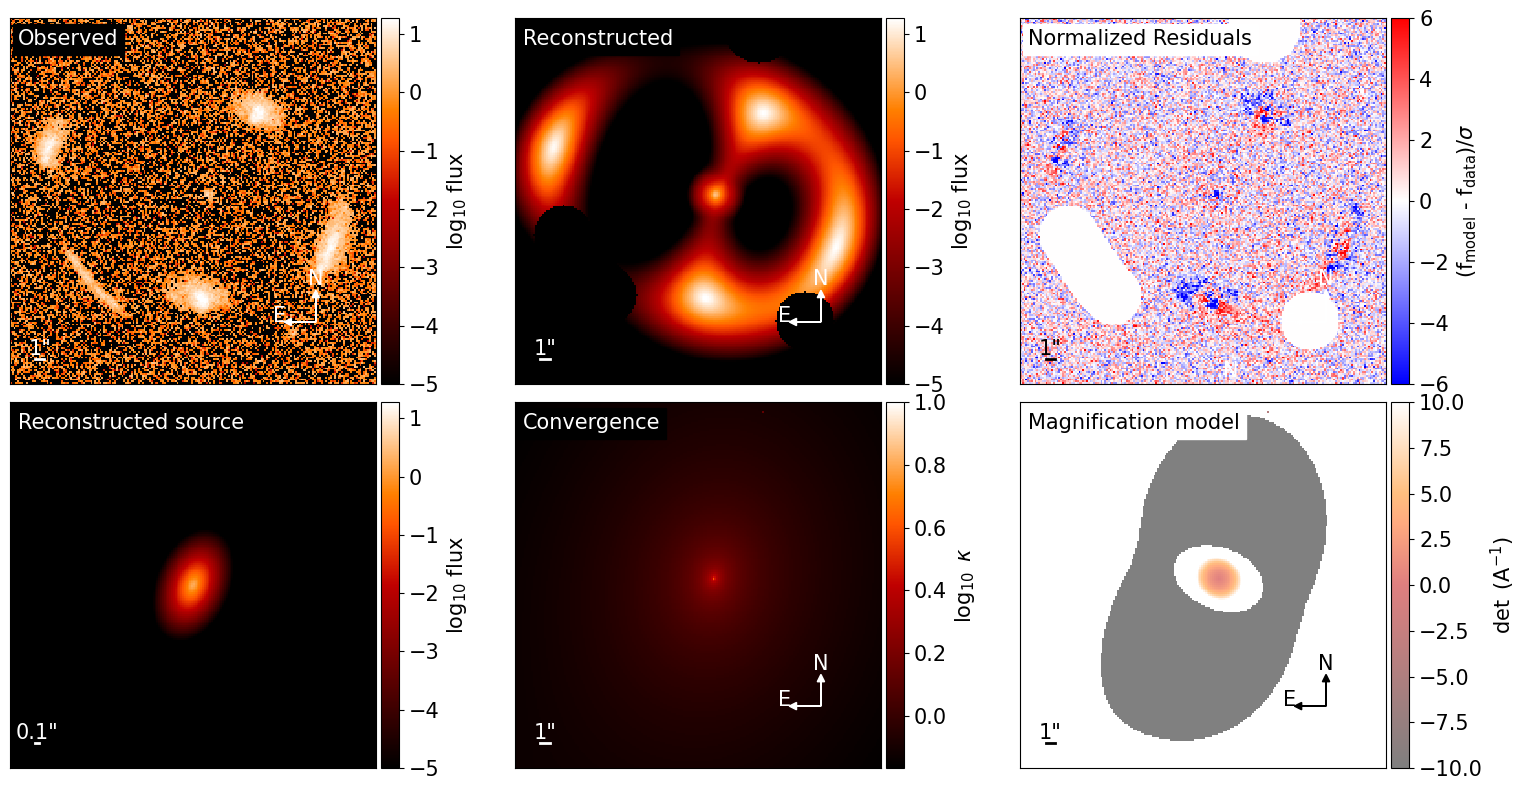

/global/homes/w/wsheu1/.conda/envs/iful/lib/python3.11/site-packages/lenstronomy/Plots/model_band_plot.py:1121: RuntimeWarning: divide by zero encountered in log10
  np.log10(model),
/global/homes/w/wsheu1/.conda/envs/iful/lib/python3.11/site-packages/lenstronomy/Plots/model_band_plot.py:1121: RuntimeWarning: invalid value encountered in log10
  np.log10(model),


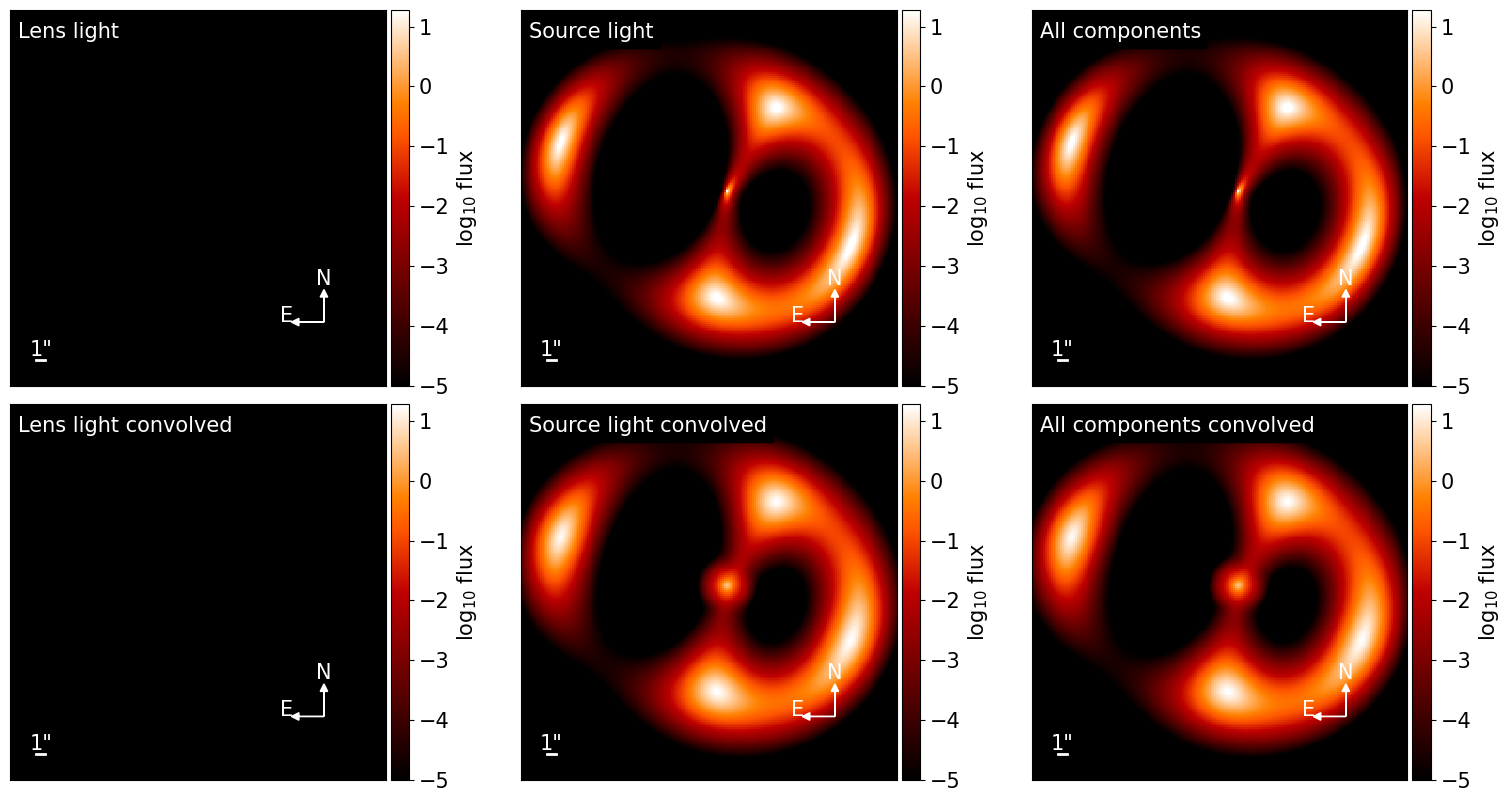

{'kwargs_lens': [{'theta_E': np.float64(12.847033248769844), 'gamma': np.float64(1.2830617180202124), 'q': np.float64(0.7782949752780802), 'phi': np.float64(-1.3864396021693932), 'center_x': np.float64(-0.8416504155413213), 'center_y': np.float64(-0.17919183185430118)}, {'theta_E': np.float64(2.552077096045611e-07), 'center_x': np.float64(-6.199999974592174), 'center_y': np.float64(17.999999954349732)}, {'theta_E': np.float64(1.3740570934670437), 'center_x': np.float64(27.399999567933264), 'center_y': np.float64(-28.999999808979737)}, {'gamma1': np.float64(-0.048922691302701146), 'gamma2': np.float64(-0.013662330946405269), 'ra_0': 0, 'dec_0': 0}], 'kwargs_source': [{'amp': np.float64(192.50880094569106), 'R_sersic': np.float64(0.18929162228901783), 'n_sersic': np.float64(0.893897696523191), 'e1': np.float64(-0.16168987079141278), 'e2': np.float64(-0.15896681477768024), 'center_x': np.float64(0.5132925666388815), 'center_y': np.float64(-1.097204677612889)}], 'kwargs_lens_light': [], 'k

In [11]:
modelPlot = ModelPlot(
    fitting_seq.multi_band_list,
    kwargs_model,
    kwargs_result,
    arrow_size=0.02,
    cmap_string="gist_heat",
    linear_solver=kwargs_constraints.get("linear_solver", True),
    image_likelihood_mask_list=np.array([imset4.mask]),
)

# multi_band_list_sim = copy.deepcopy(multi_band_list)
psfk_f160w_init = fitting_seq.multi_band_list[0][1]
# multi_band_list_sim[0][1] = psfk_f475x

f, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=False, sharey=False)

modelPlot.data_plot(ax=axes[0, 0])
modelPlot.model_plot(ax=axes[0, 1])
modelPlot.normalized_residual_plot(ax=axes[0, 2], v_min=-6, v_max=6)
modelPlot.source_plot(ax=axes[1, 0], deltaPix_source=0.05, numPix=200)
modelPlot.convergence_plot(ax=axes[1, 1], v_max=1)
modelPlot.magnification_plot(ax=axes[1, 2])
f.tight_layout()
f.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.0, hspace=0.05)
plt.show()

f, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=False, sharey=False)

modelPlot.decomposition_plot(
    ax=axes[0, 0], text="Lens light", lens_light_add=True, unconvolved=True
)
modelPlot.decomposition_plot(
    ax=axes[1, 0], text="Lens light convolved", lens_light_add=True
)
modelPlot.decomposition_plot(
    ax=axes[0, 1], text="Source light", source_add=True, unconvolved=True
)
modelPlot.decomposition_plot(
    ax=axes[1, 1], text="Source light convolved", source_add=True
)
modelPlot.decomposition_plot(
    ax=axes[0, 2],
    text="All components",
    source_add=True,
    lens_light_add=True,
    unconvolved=True,
)
modelPlot.decomposition_plot(
    ax=axes[1, 2],
    text="All components convolved",
    source_add=True,
    lens_light_add=True,
    point_source_add=True,
)
f.tight_layout()
f.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.0, hspace=0.05)
plt.show()

print(kwargs_result)
# print(get_p_value(fitting_seq, kwargs_model, mask))

In [12]:
with open("s4_models/flatmodel4.pickle", "wb") as handle:
    pickle.dump(flatmodel4, handle, protocol=pickle.HIGHEST_PROTOCOL)

# MCMC

In [13]:
bf = f"s4_models/flat_model_backup.hdf5"

multi_band_list_sim = copy.deepcopy(fitting_seq.multi_band_list)

first = not os.path.isfile(bf)
convergence = False
convergence_final = False
walker_ratio = 15

converged_b4 = os.path.isfile(f"s4_models/flat_chains.pickle")

max_interations, moves = 300, [(emcee.moves.StretchMove(), 1.0)]

if not os.path.isfile(f"s4_models/bandend_i.txt"):
    os.system(f"touch s4_models/bandend_i.txt")
    with open(f"s4_models/bandend_i.txt", "w") as f:
        f.write("0")
with open(f"s4_models/bandend_i.txt") as f:
    bandend_i = int(f.readlines()[-1])

while True:
    if not converged_b4:
        bandend_i += 1
        print(f"run {bandend_i}")

    if converged_b4:
        fitting_kwargs_list = [
            ["update_settings", {"kwargs_likelihood": {"prior_lens": []}}],
            [
                "MCMC",
                {
                    "n_burn": 0,
                    "n_run": 0,
                    "walkerRatio": walker_ratio,
                    "sigma_scale": 0.1,
                    "threadCount": threadCount,
                    "backend_filename": bf,
                    "moves": moves,
                    "start_from_backend": True,
                },
            ],
        ]

    elif convergence:
        fitting_kwargs_list = [
            ["update_settings", {"kwargs_likelihood": {"prior_lens": []}}],
            [
                "MCMC",
                {
                    "n_burn": 0,
                    "n_run": 500,
                    "walkerRatio": walker_ratio,
                    "sigma_scale": 0.1,
                    "threadCount": threadCount,
                    "backend_filename": bf,
                    "moves": moves,
                    "start_from_backend": True,
                },
            ],
        ]
        convergence_final = True

    elif first:
        fitting_kwargs_list = [
            ["update_settings", {"kwargs_likelihood": {"prior_lens": []}}],
            [
                "MCMC",
                {
                    "n_burn": 0,
                    "n_run": 5000,
                    "walkerRatio": walker_ratio,
                    "sigma_scale": 0.05,  # rtp(600)
                    "threadCount": threadCount,
                    "backend_filename": bf,
                    "moves": moves,
                    "start_from_backend": False,
                },
            ],
        ]

    else:
        fitting_kwargs_list = [
            ["update_settings", {"kwargs_likelihood": {"prior_lens": []}}],
            [
                "MCMC",
                {
                    "n_burn": 0,
                    "n_run": 150,
                    "walkerRatio": walker_ratio,
                    "sigma_scale": 0.05,
                    "threadCount": threadCount,
                    "backend_filename": bf,
                    "moves": moves,
                    "start_from_backend": True,
                },
            ],
        ]

    chain_list = fitting_seq.fit_sequence(fitting_kwargs_list)
    _, samples_mcmc, param_mcmc, _ = chain_list[-1]
    n_walkers = len(param_mcmc) * walker_ratio

    samples_mcmc = samples_mcmc[-n_walkers * 300 :, :]
    gl_stat = np.array([samples_mcmc[i::n_walkers, :] for i in np.arange(n_walkers)])

    with open(f"s4_models/bandend_i.txt", "w") as f:
        f.write(f"{bandend_i}")

    first = False
    if converged_b4 or convergence_final:
        break
    elif bandend_i > max_interations:
        os.system(f"touch s4_models/fail_to_converge.txt")
        break

    # elif not convergence:
    pruned_collapsed_chains_first, pruned_collapsed_chains_second = prune_mcmc_chains(
        gl_stat, split=True
    )
    first_mean = np.mean(pruned_collapsed_chains_first, axis=0)
    first_std = np.std(pruned_collapsed_chains_first, axis=0)

    second_mean = np.mean(pruned_collapsed_chains_second, axis=0)
    second_std = np.std(pruned_collapsed_chains_second, axis=0)

    not_phis = [("phi" not in pmc and "amp" not in pmc) for pmc in param_mcmc]
    param_not_phi = [pm for npp, pm in zip(not_phis, param_mcmc) if npp]
    mean_conv = [
        np.abs(fm - sm) <= (np.mean([sst, fs]))
        for npp, fs, fm, sst, sm in zip(
            not_phis, first_std, first_mean, second_std, second_mean
        )
        if npp
    ]
    std_conv = [
        np.max([sst, fs]) / np.min([sst, fs]) <= 1.25
        for npp, fs, fm, sst, sm in zip(
            not_phis, first_std, first_mean, second_std, second_mean
        )
        if npp
    ]

    convergence = np.all([mean_conv, std_conv])

    print(f"CONVERGENCE : {convergence}")
    print__str = "param: mean_conv, std_conv \n "
    for p, mc, sc in zip(param_not_phi, mean_conv, std_conv):
        print__str += f"{p}: {mc}, {sc} \n "
    print(print__str)

os.system(f"rm s4_models/bandend_i.txt")

2026-04-24 13:22:34,458 - lenstronomy.Sampling.Pool.pool - INFO - Running with MultiPool on 60 cores


run 1
MCMC selected. Sampling with default option emcee.


100%|██████████| 5000/5000 [4:56:58<00:00,  3.56s/it]  


Computing the MCMC...
Number of walkers =  240
Burn-in iterations:  0
Sampling iterations (in current run): 5000
17822.540122270584 time taken for MCMC sampling


2026-04-24 18:19:38,206 - lenstronomy.Sampling.Pool.pool - INFO - Running with MultiPool on 60 cores


Processing MCMC output: 240 chains, 300 iterations, 16 parameters.
-> Pruned 11 chains.
   - Stagnant (low relative var): 0
   - Outliers (bad convergence): 11
CONVERGENCE : True
param: mean_conv, std_conv 
 theta_E_lens0: True, True 
 gamma_lens0: True, True 
 q_lens0: True, True 
 center_x_lens0: True, True 
 center_y_lens0: True, True 
 theta_E_lens1: True, True 
 theta_E_lens2: True, True 
 gamma1_lens3: True, True 
 gamma2_lens3: True, True 
 R_sersic_source_light0: True, True 
 n_sersic_source_light0: True, True 
 e1_source_light0: True, True 
 e2_source_light0: True, True 
 center_x_source_light0: True, True 
 center_y_source_light0: True, True 
 
run 2
MCMC selected. Sampling with default option emcee.
re-using previous samples to initialize the next MCMC run.


100%|██████████| 500/500 [28:42<00:00,  3.44s/it]


Computing the MCMC...
Number of walkers =  240
Burn-in iterations:  0
Sampling iterations (in current run): 500
1722.3990051746368 time taken for MCMC sampling


0

Processing MCMC output: 240 chains, 300 iterations, 16 parameters.
-> Pruned 11 chains.
   - Stagnant (low relative var): 0
   - Outliers (bad convergence): 11


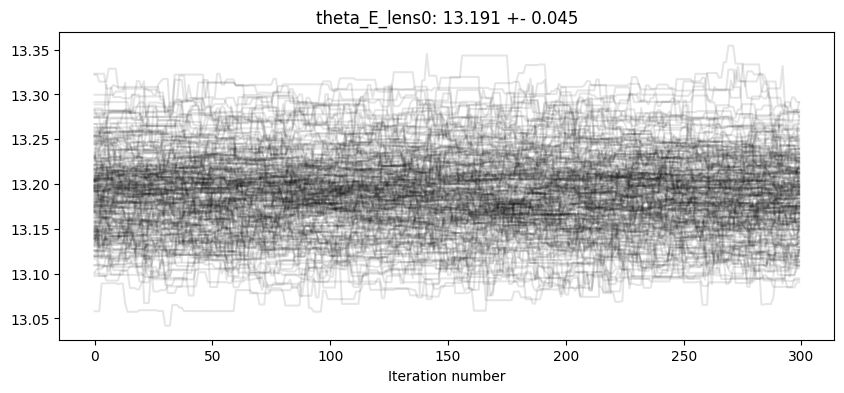

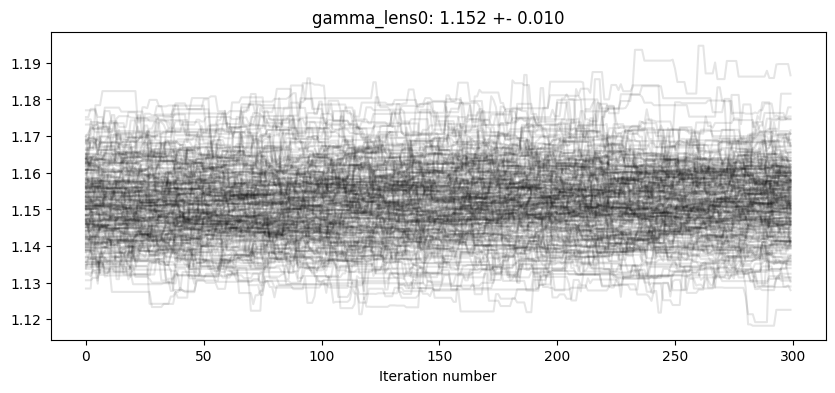

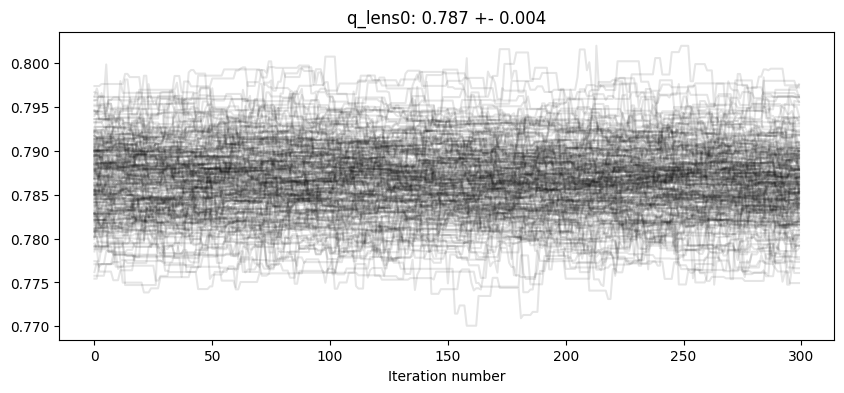

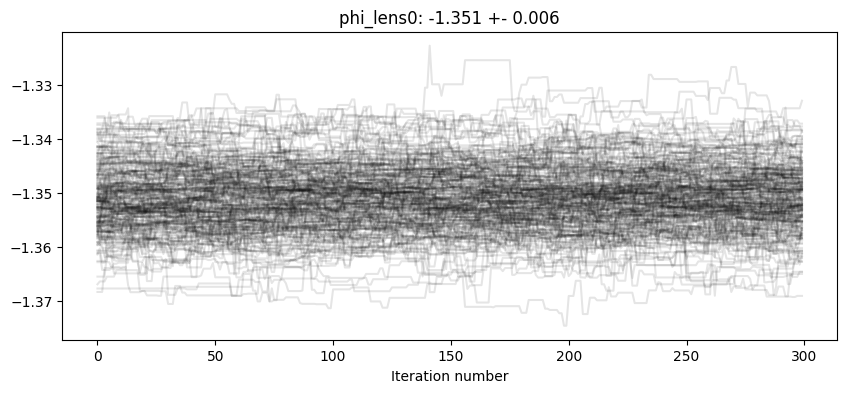

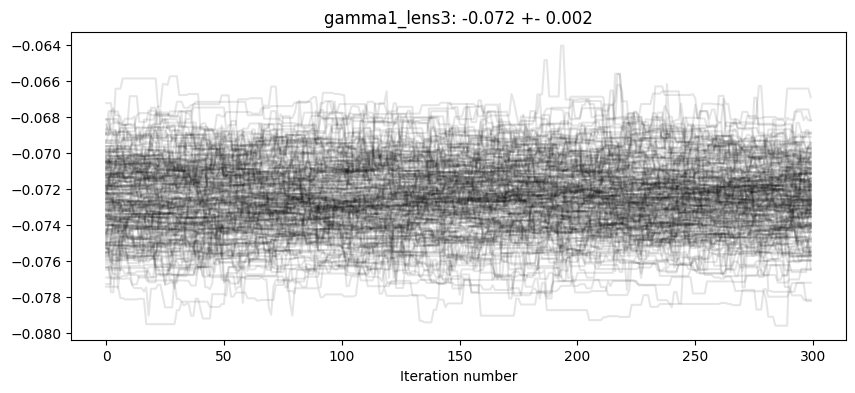

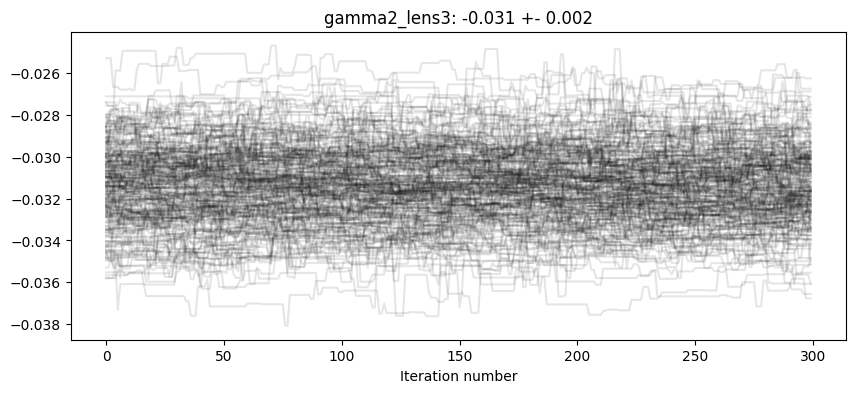

(6, 68700)

In [14]:
want = [
    "theta_E_lens0",
    "gamma_lens0",
    "q_lens0",
    "phi_lens0",
    "gamma1_lens3",
    "gamma2_lens3",
]
indices = [np.where(np.array(param_mcmc) == n)[0][0] for n in want]

samples_mcmc_t = samples_mcmc[-n_walkers * 300 :, :]
gl_stat = np.array([samples_mcmc_t[i::n_walkers, :] for i in np.arange(n_walkers)])

walker_samp = prune_mcmc_chains(
    gl_stat, split=False, deviation_threshold=4, stagnancy_threshold=0.01
)
all_vals = []

for i in indices:
    sub_want = []
    plt.figure(figsize=(10, 4))

    sp = walker_samp[:, :, i]

    for walker in range(sp.shape[0]):
        wal_chain = sp[walker, :]
        sub_want += list(wal_chain)
        plt.plot(wal_chain, alpha=0.1, c="black")

    all_vals += [sub_want]

    plt.xlabel("Iteration number")
    plt.title(f"{param_mcmc[i]}: {np.mean(sp):.3f} +- {np.std(sp):.3f}")
    plt.show()
all_vals = np.array(all_vals)
all_vals.shape

-4.238438045684196 reduced X^2 of all evaluated imaging data combined (without degrees of freedom subtracted).
reduced chi^2 of data  0 =  4.2384380456841955


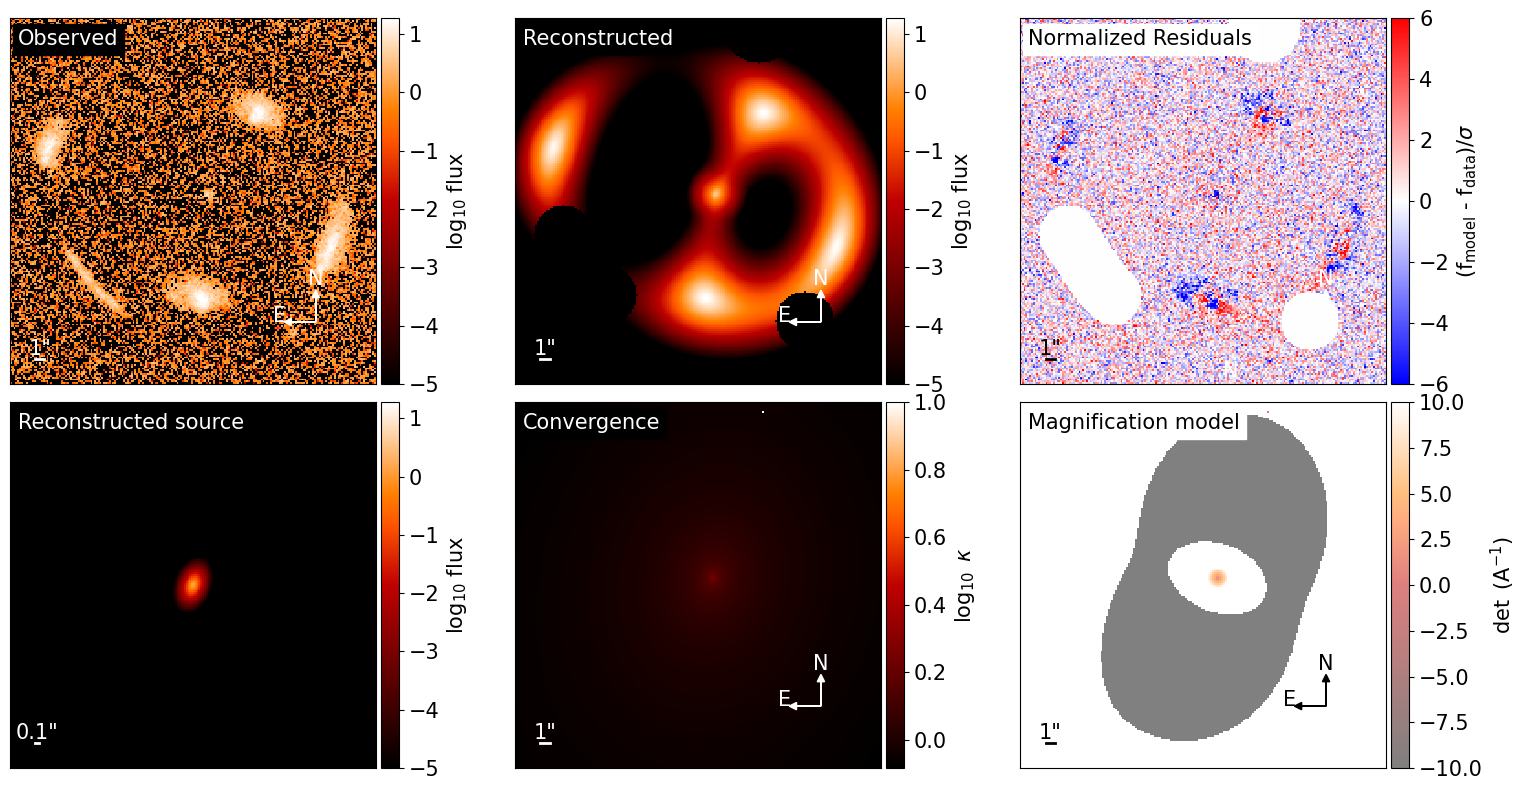

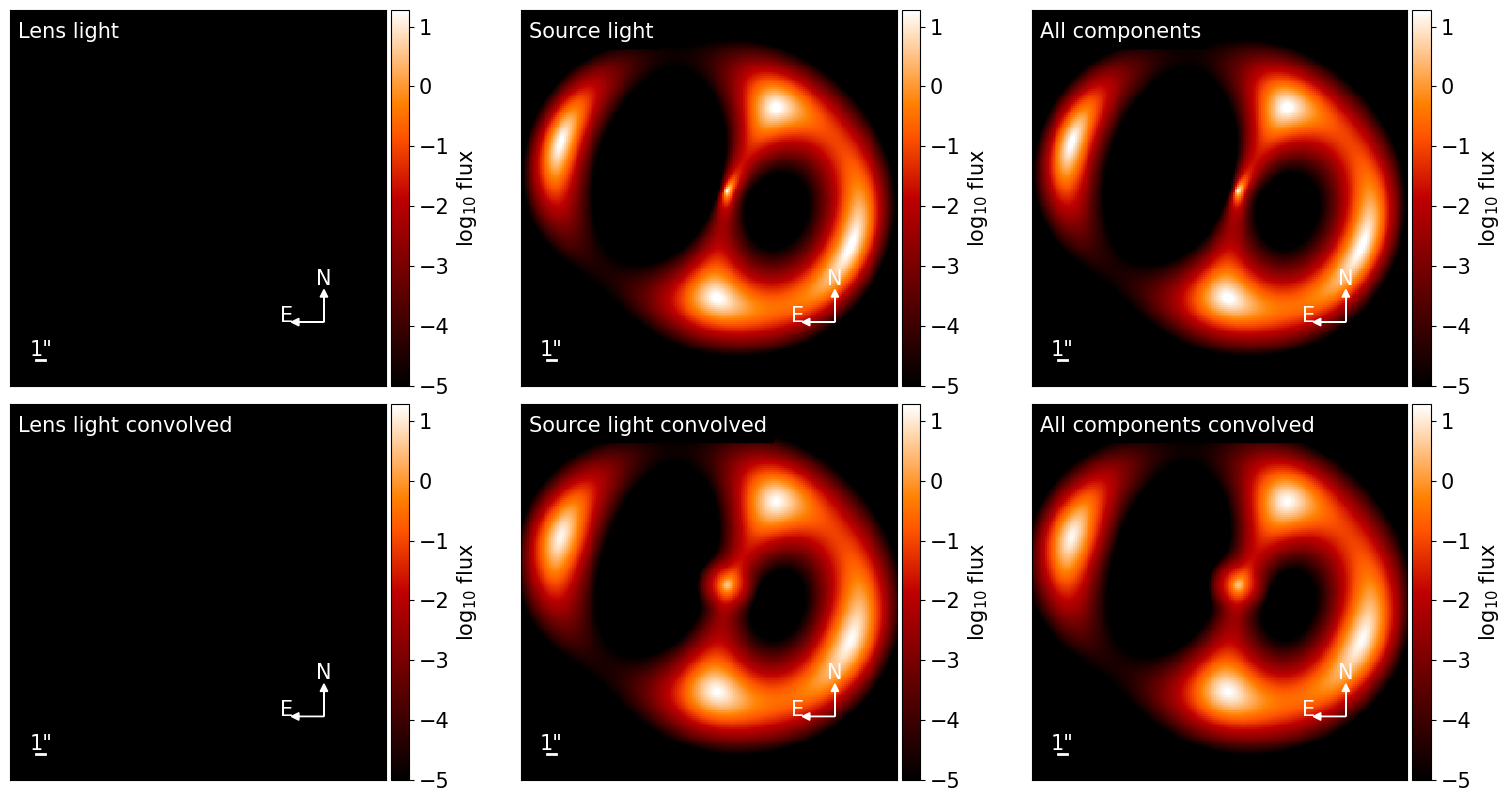

{'kwargs_lens': [{'theta_E': np.float64(13.182106713768496), 'gamma': np.float64(1.145720389453543), 'q': np.float64(0.788784784887624), 'phi': np.float64(-1.3511480203206452), 'center_x': np.float64(-0.7304451000991866), 'center_y': np.float64(-0.11846878150883332)}, {'theta_E': np.float64(1.9102837679534053e-05), 'center_x': np.float64(-6.199999974592174), 'center_y': np.float64(17.999999954349732)}, {'theta_E': np.float64(0.5107456951483312), 'center_x': np.float64(27.399999567933264), 'center_y': np.float64(-28.999999808979737)}, {'gamma1': np.float64(-0.07294138100261721), 'gamma2': np.float64(-0.031643600161128424), 'ra_0': 0, 'dec_0': 0}], 'kwargs_source': [{'amp': 1, 'R_sersic': np.float64(0.09817833836001354), 'n_sersic': np.float64(0.8763669028416753), 'e1': np.float64(-0.15792617000455678), 'e2': np.float64(-0.13944649895034508), 'center_x': np.float64(-0.19662036844389696), 'center_y': np.float64(-0.4695417373339972)}], 'kwargs_lens_light': [], 'kwargs_ps': [], 'kwargs_spec

In [15]:
modelPlot = ModelPlot(
    fitting_seq.multi_band_list,
    kwargs_model,
    fitting_seq.best_fit(),
    arrow_size=0.02,
    cmap_string="gist_heat",
    linear_solver=kwargs_constraints.get("linear_solver", True),
    image_likelihood_mask_list=np.array([imset4.mask]),
)

# multi_band_list_sim = copy.deepcopy(multi_band_list)
psfk_f160w_init = fitting_seq.multi_band_list[0][1]
# multi_band_list_sim[0][1] = psfk_f475x

f, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=False, sharey=False)

modelPlot.data_plot(ax=axes[0, 0])
modelPlot.model_plot(ax=axes[0, 1])
modelPlot.normalized_residual_plot(ax=axes[0, 2], v_min=-6, v_max=6)
modelPlot.source_plot(ax=axes[1, 0], deltaPix_source=0.05, numPix=200)
modelPlot.convergence_plot(ax=axes[1, 1], v_max=1)
modelPlot.magnification_plot(ax=axes[1, 2])
f.tight_layout()
f.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.0, hspace=0.05)
plt.show()

f, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=False, sharey=False)

modelPlot.decomposition_plot(
    ax=axes[0, 0], text="Lens light", lens_light_add=True, unconvolved=True
)
modelPlot.decomposition_plot(
    ax=axes[1, 0], text="Lens light convolved", lens_light_add=True
)
modelPlot.decomposition_plot(
    ax=axes[0, 1], text="Source light", source_add=True, unconvolved=True
)
modelPlot.decomposition_plot(
    ax=axes[1, 1], text="Source light convolved", source_add=True
)
modelPlot.decomposition_plot(
    ax=axes[0, 2],
    text="All components",
    source_add=True,
    lens_light_add=True,
    unconvolved=True,
)
modelPlot.decomposition_plot(
    ax=axes[1, 2],
    text="All components convolved",
    source_add=True,
    lens_light_add=True,
    point_source_add=True,
)
f.tight_layout()
f.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.0, hspace=0.05)
plt.show()

print(fitting_seq.best_fit())
# print(get_p_value(fitting_seq, kwargs_model, mask))

In [16]:
param_for_corner = [
    r"$\theta_{\rm E}$",
    r"$\gamma$",
    r"$q_{\rm m}$",
    r"$\phi_{\rm m}$",
    r"$\gamma_{\rm ext}$",
]

# phis, qs = param_util.ellipticity2phi_q(all_vals[2], all_vals[3])
_, gamma_exts = param_util.shear_cartesian2polar(all_vals[4], all_vals[5])

final_dict_res_t = {}
final_dict_res_t[param_for_corner[0]] = copy.deepcopy(all_vals[0])
final_dict_res_t[param_for_corner[1]] = copy.deepcopy(all_vals[1])
final_dict_res_t[param_for_corner[2]] = copy.deepcopy(all_vals[2])
final_dict_res_t[param_for_corner[3]] = copy.deepcopy(all_vals[3]) * 180 / np.pi
final_dict_res_t[param_for_corner[4]] = copy.deepcopy(gamma_exts)

In [17]:
flatmodel4.init_fitting_seq = fitting_seq
flatmodel4.init_fit = kwargs_result
with open("s4_models/flatmodel4.pickle", "wb") as handle:
    pickle.dump(flatmodel4, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [18]:
with open("s4_models/flat_chains.pickle", "wb") as handle:
    pickle.dump(final_dict_res_t, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [19]:
1

1